In [1]:
!pip install anndata==0.8.0

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors
from sklearn.manifold import TSNE
import pickle
import matplotlib.colors as mcolors
import itertools
import numpy as np

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [21]:
fn = '../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_NN_04142026.h5ad'

In [22]:
sam=SAM()
sam.load_data(fn)

In [27]:
Xtsne = TSNE(n_components=2, metric = 'cosine').fit_transform(sam.adata.obsm['X_pca'])

/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:827: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  FutureWarning,


In [28]:
sam.adata.obsm['X_tsne'] = Xtsne

In [29]:
sam.save_anndata(fn)

In [7]:
with open('CT_color_mapping_06262026.pkl', 'rb') as f:
    CT_color_mapping = pickle.load(f)

In [19]:
nt_mapping = {'Gaba-Chol':'#73E785',
             'Chol':'#73E785',
             'Glut-Chol':'#73E785',
             'Glut-Gaba-Dopa':'#FCF04B',
             'Gaba-Dopa':'#FCF04B',
             'Glut-Dopa':'#FCF04B',
             'Gaba-Dopa-Chol':'#FCF04B',
             'Dopa':'#FCF04B',
             'Gly':'#820E57',
             'Glut-Gly':'#820E57',
             'Glut-Gaba-Gly':'#820E57',
             'Hist':'#FF7621',
             'Gaba':'#FF3358',
             'Glut':'#2B93DF',
             'Glut-Gaba':'#0A9964',
             'Gaba-Gly':'#820E57',
             'Gaba-Hist':'#FF7621',
             'Nora':'#03EDFF',
             'Gaba-Sert':'#4f2e91ff',
             'Glut-Sert':'#4f2e91ff',
              '"Glut-Sert"':'#4f2e91ff',
             'Glut-Gaba-Sert':'#4f2e91ff',
             'Gaba-Dopa-Sert':'#4f2e91ff',
             'Glut-Gaba-Sert-Hist':'#4f2e91ff',
             'unclear':'lightgrey',
             'Sert':'#4f2e91ff',
             'Glut-Gaba-Hist':'#FF7621'}

In [ ]:
CT_color_mapping['Unlabeled'] = 'grey'

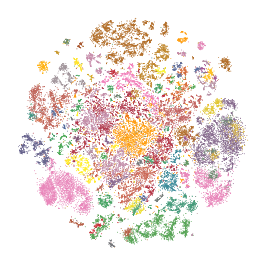

In [12]:
#Figure 1B 02272025
plt.rcParams["figure.figsize"] = (3.8,3.8)
g = sc.pl.tsne(sam.adata, color = 'ss_subclass_nounlabeled_nmm_v3_nn', s = 2, palette = CT_color_mapping, frameon=False, return_fig=True, legend_loc = None)
plt.title(None)
plt.tight_layout()
#plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
g.patch.set_facecolor('black')
g.patch.set_alpha(0)
g.savefig('Figures/Figures_07032026/DR_sss_subclass_v3_07012026.png', bbox_inches='tight', dpi = 300)
plt.show()

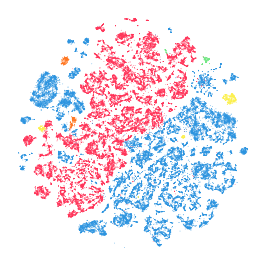

In [23]:
plt.rcParams["figure.figsize"] = (3.8,3.8)
g = sc.pl.tsne(sam.adata, color = 'neurotransmitter_v3', s = 2,palette = nt_mapping , frameon=False, return_fig=True,legend_loc=None)
plt.title(None)
plt.tight_layout()
#plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
#plt.legend([])
g.patch.set_facecolor('black')
g.patch.set_alpha(0)
g.savefig('../../Figures/Figures_08022026/MO_ss_subclass_v3_neurotransmitterv2_08042026.png', bbox_inches='tight', dpi = 600)
plt.show()

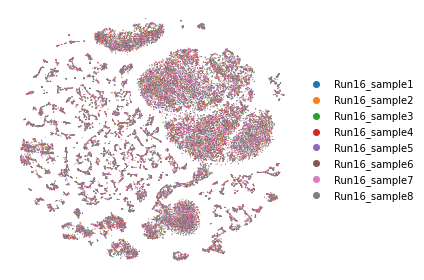

In [9]:
#Figure 1B 02272025
plt.rcParams["figure.figsize"] = (7,5)
g = sc.pl.tsne(sam.adata, color = 'key', s = 4, frameon=False, return_fig=True)
plt.title(None)
plt.tight_layout()
#plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
g.patch.set_facecolor('black')
g.patch.set_alpha(0)
#g.savefig('Figures/Figures_01022026/MV_subclass_id_label_mapping_12262025.png', bbox_inches='tight', dpi = 600)
plt.show()